# B5 Pipeline - Hyperparameter Tuning
Extends the B4 baseline with Optuna-based hyperparameter optimization.
- (tech + fundamentals + sector + FinBERT + news sentiment)
- Logistic Regression: tune C and penalty (L1/L2)
- Random Forest: tune depth, estimators, leaf size, max_features
- XGBoost: tune learning rate, depth, subsample, regularization
- Ridge Regression: replaces Linear Regression (B4 R² = −88.7) with L2 regularization, tune alpha
- Evaluation: same 5-fold walk-forward protocol as B1–B4

In [1]:
import polars as pl
import numpy as np
import os, joblib, pickle
from datetime import date

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score,
)

import optuna
import warnings
warnings.filterwarnings("ignore")

print(f"Optuna version: {optuna.__version__}")

Optuna version: 4.9.0


c:\Users\satya\OneDrive\Documents\Work\Post-Earnings-Forecast\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Data Loading (identical to B4)

In [2]:
# ── Tech modeling table
tech_path = "../data/model_staging/tech_modeling_table.parquet"
df_tech   = pl.read_parquet(tech_path)
print(f"Tech table shape: {df_tech.shape}")

# ── Fundamental features
fund_path = "../data/model_staging/fundamentalIndicators/modeling_fundamentals.parquet"
df_fund   = pl.read_parquet(fund_path)

df_fund = df_fund.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "eps_growth_qoq", "revenue_growth_qoq",
    "gross_margin",     "gross_margin_qoq",
    "debt_to_equity",   "debt_to_equity_qoq",
    "fcf_margin",       "fcf_margin_qoq",
    "roe",              "roe_qoq",
    "surprisePercentage"
])

# ── FinBERT transcript sentiment
df_finbert = pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet")
df_finbert = df_finbert.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "pos_prob", "neg_prob",
])
print(f"FinBERT shape: {df_finbert.shape}")

# ── News sentiment (pre/post earnings window)
df_nz = pl.read_parquet("../data/model_staging/nz_sentiment.parquet")
df_nz = df_nz.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "overall_sentiment_score_pre",  "ticker_sentiment_score_pre",
    "overall_sentiment_score_post", "ticker_sentiment_score_post",
])
print(f"NZ sentiment shape: {df_nz.shape}")

# ── Merge all onto tech table
df_model = df_tech.join(df_fund,    on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_finbert, on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_nz,     on=["symbol", "earnings_date"], how="left")

print(f"Combined table shape: {df_model.shape}")
print(f"Target direction distribution:\n{df_model['target_direction'].value_counts().sort('target_direction')}")
print(f"Multi-class: 0=<2%  |  1=2-4%  |  2=>4%")

Tech table shape: (24048, 225)
FinBERT shape: (24294, 4)
NZ sentiment shape: (24294, 6)
Combined table shape: (24048, 242)
Target: 52.4% positive


In [3]:
# ── Sector dummies
df_sector_raw = pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet")
df_sector     = df_sector_raw.select(["symbol", "sector"]).unique()

df_sector = df_sector.with_columns(
    pl.col("sector").fill_null("Unknown")
)

sectors   = sorted(df_sector["sector"].unique().to_list())
df_sector = df_sector.with_columns([
    (pl.col("sector") == s).cast(pl.Int8).alias(f"sector_{s.replace(' ', '_')}")
    for s in sectors
]).drop("sector")

print(f"Sectors: {sectors}")
print(f"Unique symbols in sector map: {df_sector.shape[0]}")

df_model     = df_model.join(df_sector, on="symbol", how="left")
sector_cols  = [c for c in df_model.columns if c.startswith("sector_")]
print(f"Shape after sector join: {df_model.shape}")
print(f"Sector columns: {sector_cols}")

Sectors: ['Basic Materials', 'Communication Services', 'Consumer Cyclical', 'Consumer Defensive', 'Energy', 'Financial Services', 'Healthcare', 'Industrials', 'Real Estate', 'Technology', 'Unknown', 'Utilities']
Unique symbols in sector map: 503
Shape after sector join: (24048, 254)
Sector columns: ['sector_Basic_Materials', 'sector_Communication_Services', 'sector_Consumer_Cyclical', 'sector_Consumer_Defensive', 'sector_Energy', 'sector_Financial_Services', 'sector_Healthcare', 'sector_Industrials', 'sector_Real_Estate', 'sector_Technology', 'sector_Unknown', 'sector_Utilities']


---
## 2. Fold Setup (identical to B4)

In [4]:
TRAIN_WINDOW = 7
FOLDS = [
    (date(y - TRAIN_WINDOW, 1, 1), date(y, 1, 1), date(y + 1, 1, 1))
    for y in range(2021, 2026)
]

EXCLUDE_COLS = [
    "symbol", "earnings_date", "entry_price", "target_return",
    "target_direction", "max_high", "min_high", "max_day", "min_day",
]
feature_cols = [c for c in df_model.columns if c not in EXCLUDE_COLS]
print(f"Total features: {len(feature_cols)}")

folds_data = []

for fold_num, (train_start, test_start, test_end) in enumerate(FOLDS, 1):
    train = df_model.filter(
        (pl.col("earnings_date") >= train_start) & (pl.col("earnings_date") < test_start)
    )
    test = df_model.filter(
        (pl.col("earnings_date") >= test_start) & (pl.col("earnings_date") < test_end)
    )

    X_train = train.select(feature_cols).to_numpy()
    X_test  = test.select(feature_cols).to_numpy()

    X_train = np.where(np.isinf(X_train), np.nan, X_train)
    X_test  = np.where(np.isinf(X_test),  np.nan, X_test)

    imputer    = SimpleImputer(strategy="median")
    X_train    = imputer.fit_transform(X_train)
    X_test     = imputer.transform(X_test)

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    folds_data.append({
        "fold_num":    fold_num,
        "train_years": f"{train_start.year}-{test_start.year - 1}",
        "test_year":   test_start.year,
        "X_train":     X_train,    "X_test":     X_test,
        "X_train_sc":  X_train_sc, "X_test_sc":  X_test_sc,
        "y_train_cls": train["target_direction"].to_numpy(),
        "y_test_cls":  test["target_direction"].to_numpy(),
        "y_train_ret": train["target_return"].to_numpy(),
        "y_test_ret":  test["target_return"].to_numpy(),
    })

    print(f"Fold {fold_num}: train [{train_start.year}-{test_start.year-1}] "
          f"({X_train.shape[0]:,}) -> test [{test_start.year}] ({X_test.shape[0]:,})")

Total features: 245
Fold 1: train [2014-2020] (13,169) -> test [2021] (1,970)
Fold 2: train [2015-2021] (13,313) -> test [2022] (1,975)
Fold 3: train [2016-2022] (13,439) -> test [2023] (1,984)
Fold 4: train [2017-2023] (13,560) -> test [2024] (2,000)
Fold 5: train [2018-2024] (13,671) -> test [2025] (2,008)


---
## 3. B0 Baseline (from B4, for reference)

In [5]:
np.random.seed(42)

b0_clf = {"fold_acc": [], "preds": [], "true": []}
b0_reg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}

for f in folds_data:
    preds_dir = np.random.randint(0, 3, size=len(f["y_test_cls"]))
    acc = accuracy_score(f["y_test_cls"], preds_dir)
    b0_clf["fold_acc"].append(acc)
    b0_clf["preds"].extend(preds_dir)
    b0_clf["true"].extend(f["y_test_cls"])

    preds_ret = np.full(len(f["y_test_ret"]), f["y_train_ret"].mean())
    b0_reg["fold_mae"].append(mean_absolute_error(f["y_test_ret"], preds_ret))
    b0_reg["fold_rmse"].append(np.sqrt(mean_squared_error(f["y_test_ret"], preds_ret)))
    b0_reg["preds"].extend(preds_ret)
    b0_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']}: DA={acc:.4f}")

print(f"\nB0 Baseline — Avg DA:   {np.mean(b0_clf['fold_acc']):.4f}")
print(f"B0 Baseline — Avg MAE:  {np.mean(b0_reg['fold_mae']):.4f}")
print(f"B0 Baseline — Avg RMSE: {np.mean(b0_reg['fold_rmse']):.4f}")

Fold 1: DA=0.5015
Fold 2: DA=0.4947
Fold 3: DA=0.5040
Fold 4: DA=0.4765
Fold 5: DA=0.4940

B0 Baseline — Avg DA:   0.4942
B0 Baseline — Avg MAE:  0.0310
B0 Baseline — Avg RMSE: 0.0458


---
## 4. Optuna Tuning

We use Fold 1's training data (2014–2020) split temporally:
- **train_sub**: 2014–2018 (used to train during tuning)
- **val_sub**: 2019 (used to evaluate during tuning)

In [6]:
# Held-out validation split from Fold 1 training data for Optuna tuning
val_start = date(2019, 1, 1)
val_end   = date(2020, 1, 1)

train1 = df_model.filter(
    (pl.col("earnings_date") >= FOLDS[0][0]) & (pl.col("earnings_date") < val_start)
)
val1 = df_model.filter(
    (pl.col("earnings_date") >= val_start) & (pl.col("earnings_date") < val_end)
)

# Fit on train only, transform both
X_tr = train1.select(feature_cols).to_numpy()
X_val = val1.select(feature_cols).to_numpy()

X_tr = np.where(np.isinf(X_tr), np.nan, X_tr)
X_val = np.where(np.isinf(X_val), np.nan, X_val)

imputer = SimpleImputer(strategy="median")
X_tr = imputer.fit_transform(X_tr)
X_val = imputer.transform(X_val)

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)

train_sub = {
    "X": X_tr, "X_sc": X_tr_sc,
    "y_cls": train1["target_direction"].to_numpy(),
    "y_ret": train1["target_return"].to_numpy(),
}
val_sub = {
    "X": X_val, "X_sc": X_val_sc,
    "y_cls": val1["target_direction"].to_numpy(),
    "y_ret": val1["target_return"].to_numpy(),
}

print(f"Train sub: {X_tr.shape[0]:,} samples (2014-2018)")
print(f"Val sub:   {X_val.shape[0]:,} samples (2019)")

Train sub: 9,314 samples (2014-2018)
Val sub:   1,916 samples (2019)


### 4a. Logistic Regression Tuning

In [7]:
def objective_lr(trial):
    C       = trial.suggest_float("C", 1e-3, 1e3, log=True)
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    solver  = "saga"

    model = LogisticRegression(
        C=C, penalty=penalty, solver=solver,
        max_iter=2000, class_weight="balanced",
        random_state=42, n_jobs=-1,
    )
    model.fit(train_sub["X_sc"], train_sub["y_cls"])
    preds = model.predict(val_sub["X_sc"])
    return accuracy_score(val_sub["y_cls"], preds)

study_lr = optuna.create_study(direction="maximize", study_name="lr_clf")
study_lr.optimize(objective_lr, n_trials=30, show_progress_bar=True)

print(f"\nBest LR params: {study_lr.best_params}")
print(f"Best val DA: {study_lr.best_value:.4f}")

[I 2026-06-28 17:37:06,208] A new study created in memory with name: lr_clf
Best trial: 0. Best value: 0.558455:   3%|▎         | 1/30 [01:38<47:33, 98.40s/it]

[I 2026-06-28 17:38:44,606] Trial 0 finished with value: 0.558455114822547 and parameters: {'C': 48.793574812829505, 'penalty': 'l1'}. Best is trial 0 with value: 0.558455114822547.


Best trial: 0. Best value: 0.558455:   7%|▋         | 2/30 [02:42<36:32, 78.32s/it]

[I 2026-06-28 17:39:48,873] Trial 1 finished with value: 0.558455114822547 and parameters: {'C': 1.1983366060762206, 'penalty': 'l2'}. Best is trial 0 with value: 0.558455114822547.


Best trial: 0. Best value: 0.558455:  10%|█         | 3/30 [03:36<30:09, 67.00s/it]

...

[I 2026-06-28 17:51:14,716] Trial 27 finished with value: 0.5793319415448852 and parameters: {'C': 0.006344085995058094, 'penalty': 'l1'}. Best is trial 10 with value: 0.5861169102296451.


Best trial: 10. Best value: 0.586117:  97%|█████████▋| 29/30 [14:43<00:21, 21.11s/it]

[I 2026-06-28 17:51:49,663] Trial 28 finished with value: 0.5741127348643006 and parameters: {'C': 0.0403375322237848, 'penalty': 'l1'}. Best is trial 10 with value: 0.5861169102296451.


Best trial: 10. Best value: 0.586117: 100%|██████████| 30/30 [14:57<00:00, 29.91s/it]

[I 2026-06-28 17:52:03,619] Trial 29 finished with value: 0.5835073068893528 and parameters: {'C': 0.003275381256400477, 'penalty': 'l1'}. Best is trial 10 with value: 0.5861169102296451.

Best LR params: {'C': 0.0015414701026821545, 'penalty': 'l1'}
Best val DA: 0.5861


### 4b. Ridge Regression Tuning (replaces LinearRegression)

In [8]:
def objective_ridge(trial):
    alpha = trial.suggest_float("alpha", 1e-2, 1e3, log=True)

    model = Ridge(alpha=alpha, random_state=42)
    model.fit(train_sub["X_sc"], train_sub["y_ret"])
    preds = model.predict(val_sub["X_sc"])
    return -mean_absolute_error(val_sub["y_ret"], preds)

study_ridge = optuna.create_study(direction="maximize", study_name="ridge_reg")
study_ridge.optimize(objective_ridge, n_trials=30, show_progress_bar=True)

print(f"\nBest Ridge params: {study_ridge.best_params}")
print(f"Best val MAE: {-study_ridge.best_value:.4f}")

[I 2026-06-28 17:54:26,614] A new study created in memory with name: ridge_reg
Best trial: 3. Best value: -0.020888:  20%|██        | 6/30 [00:00<00:00, 26.29it/s]

[I 2026-06-28 17:54:26,684] Trial 0 finished with value: -0.021060987438806477 and parameters: {'alpha': 49.76326139224174}. Best is trial 0 with value: -0.021060987438806477.
[I 2026-06-28 17:54:26,716] Trial 1 finished with value: -0.021113782936603747 and parameters: {'alpha': 30.39960191654039}. Best is trial 0 with value: -0.021060987438806477.
[I 2026-06-28 17:54:26,747] Trial 2 finished with value: -0.021079872253664478 and parameters: {'alpha': 41.904017963786686}. Best is trial 0 with value: -0.021060987438806477.
[I 2026-06-28 17:54:26,778] Trial 3 finished with value: -0.02088795073505096 and parameters: {'alpha': 190.2986724702598}. Best is trial 3 with value: -0.02088795073505096.
[I 2026-06-28 17:54:26,814] Trial 4 finished with value: -0.021111936707495435 and parameters: {'alpha': 30.96968554031316}. Best is trial 3 with value: -0.02088795073505096.
[I 2026-06-28 17:54:26,848] Trial 5 finished with value: -0.021437489535763587 and parameters: {'alpha': 0.332171114813502

Best trial: 13. Best value: -0.0206493:  43%|████▎     | 13/30 [00:00<00:00, 28.63it/s]

[I 2026-06-28 17:54:26,915] Trial 7 finished with value: -0.021514342758266285 and parameters: {'alpha': 0.0471058386866373}. Best is trial 3 with value: -0.02088795073505096.
[I 2026-06-28 17:54:26,948] Trial 8 finished with value: -0.021452374655266768 and parameters: {'alpha': 0.24745821139764923}. Best is trial 3 with value: -0.02088795073505096.
[I 2026-06-28 17:54:26,983] Trial 9 finished with value: -0.021367054061508833 and parameters: {'alpha': 1.2034887012418443}. Best is trial 3 with value: -0.02088795073505096.
[I 2026-06-28 17:54:27,015] Trial 10 finished with value: -0.020790438855722817 and parameters: {'alpha': 382.13220683049076}. Best is trial 10 with value: -0.020790438855722817.
[I 2026-06-28 17:54:27,047] Trial 11 finished with value: -0.020682719240747587 and parameters: {'alpha': 791.6091437039852}. Best is trial 11 with value: -0.020682719240747587.
[I 2026-06-28 17:54:27,084] Trial 12 finished with value: -0.020667530130704836 and parameters: {'alpha': 877.5936

Best trial: 13. Best value: -0.0206493:  67%|██████▋   | 20/30 [00:00<00:00, 28.78it/s]

[I 2026-06-28 17:54:27,163] Trial 14 finished with value: -0.020890273897135138 and parameters: {'alpha': 187.1003848471231}. Best is trial 13 with value: -0.02064931816681297.
[I 2026-06-28 17:54:27,198] Trial 15 finished with value: -0.02065126549167269 and parameters: {'alpha': 979.9053872879118}. Best is trial 13 with value: -0.02064931816681297.
[I 2026-06-28 17:54:27,232] Trial 16 finished with value: -0.021256662687605708 and parameters: {'alpha': 5.839849243187848}. Best is trial 13 with value: -0.02064931816681297.
[I 2026-06-28 17:54:27,264] Trial 17 finished with value: -0.02089427150062678 and parameters: {'alpha': 181.78938386324828}. Best is trial 13 with value: -0.02064931816681297.
[I 2026-06-28 17:54:27,294] Trial 18 finished with value: -0.02123400240824282 and parameters: {'alpha': 7.857751071162962}. Best is trial 13 with value: -0.02064931816681297.
[I 2026-06-28 17:54:27,329] Trial 19 finished with value: -0.020694464228420334 and parameters: {'alpha': 732.1610863

Best trial: 13. Best value: -0.0206493:  80%|████████  | 24/30 [00:00<00:00, 28.57it/s]

[I 2026-06-28 17:54:27,397] Trial 21 finished with value: -0.02065157716364938 and parameters: {'alpha': 977.8337023859561}. Best is trial 13 with value: -0.02064931816681297.
[I 2026-06-28 17:54:27,436] Trial 22 finished with value: -0.020793418258519467 and parameters: {'alpha': 374.11537106425385}. Best is trial 13 with value: -0.02064931816681297.
[I 2026-06-28 17:54:27,466] Trial 23 finished with value: -0.020656779001286932 and parameters: {'alpha': 943.7575049040662}. Best is trial 13 with value: -0.02064931816681297.
[I 2026-06-28 17:54:27,591] Trial 24 finished with value: -0.020966228560043022 and parameters: {'alpha': 107.62869886778834}. Best is trial 13 with value: -0.02064931816681297.


Best trial: 13. Best value: -0.0206493: 100%|██████████| 30/30 [00:01<00:00, 26.10it/s]

[I 2026-06-28 17:54:27,637] Trial 25 finished with value: -0.020798148512337633 and parameters: {'alpha': 361.6032729698244}. Best is trial 13 with value: -0.02064931816681297.
[I 2026-06-28 17:54:27,673] Trial 26 finished with value: -0.021015325800524464 and parameters: {'alpha': 73.69128678531463}. Best is trial 13 with value: -0.02064931816681297.
[I 2026-06-28 17:54:27,704] Trial 27 finished with value: -0.02079800174415263 and parameters: {'alpha': 361.9875503849321}. Best is trial 13 with value: -0.02064931816681297.
[I 2026-06-28 17:54:27,734] Trial 28 finished with value: -0.021198947476209363 and parameters: {'alpha': 12.016343426047586}. Best is trial 13 with value: -0.02064931816681297.
[I 2026-06-28 17:54:27,764] Trial 29 finished with value: -0.020777753994351177 and parameters: {'alpha': 417.56675674462633}. Best is trial 13 with value: -0.02064931816681297.

Best Ridge params: {'alpha': 992.9926965878374}
Best val MAE: 0.0206


### 4c. Random Forest Tuning

In [10]:
def objective_rf_clf(trial):
    n_estimators      = trial.suggest_int("n_estimators", 100, 500, step=100)
    max_depth         = trial.suggest_int("max_depth", 8, 20)
    min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 10)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    max_features      = trial.suggest_categorical("max_features", ["sqrt", 0.3, 0.5])

    model = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_leaf=min_samples_leaf, min_samples_split=min_samples_split,
        max_features=max_features,
        class_weight="balanced", random_state=42, n_jobs=-1,
    )
    model.fit(train_sub["X"], train_sub["y_cls"])
    preds = model.predict(val_sub["X"])
    return accuracy_score(val_sub["y_cls"], preds)

study_rf_clf = optuna.create_study(direction="maximize", study_name="rf_clf")
study_rf_clf.optimize(objective_rf_clf, n_trials=30, show_progress_bar=True)

print(f"\nBest RF (clf) params: {study_rf_clf.best_params}")
print(f"Best val DA: {study_rf_clf.best_value:.4f}")

[I 2026-06-28 18:02:33,102] A new study created in memory with name: rf_clf
Best trial: 0. Best value: 0.584029:   3%|▎         | 1/30 [01:10<33:59, 70.32s/it]

[I 2026-06-28 18:03:43,423] Trial 0 finished with value: 0.5840292275574113 and parameters: {'n_estimators': 400, 'max_depth': 13, 'min_samples_leaf': 6, 'min_samples_split': 9, 'max_features': 0.5}. Best is trial 0 with value: 0.5840292275574113.


Best trial: 0. Best value: 0.584029:   7%|▋         | 2/30 [02:12<30:28, 65.32s/it]

[I 2026-06-28 18:04:45,235] Trial 1 finished with value: 0.5793319415448852 and parameters: {'n_estimators': 300, 'max_depth': 14, 'min_samples_leaf': 4, 'min_samples_split': 6, 'max_features': 0.5}. Best is trial 0 with value: 0.5840292275574113.


Best trial: 2. Best value: 0.585595:  10%|█         | 3/30 [02:24<18:24, 40.92s/it]

...

[I 2026-06-28 18:16:39,094] Trial 27 finished with value: 0.5918580375782881 and parameters: {'n_estimators': 400, 'max_depth': 16, 'min_samples_leaf': 5, 'min_samples_split': 6, 'max_features': 'sqrt'}. Best is trial 16 with value: 0.5965553235908142.


Best trial: 16. Best value: 0.596555:  97%|█████████▋| 29/30 [14:21<00:20, 20.96s/it]

[I 2026-06-28 18:16:55,078] Trial 28 finished with value: 0.5876826722338204 and parameters: {'n_estimators': 500, 'max_depth': 12, 'min_samples_leaf': 7, 'min_samples_split': 3, 'max_features': 'sqrt'}. Best is trial 16 with value: 0.5965553235908142.


Best trial: 16. Best value: 0.596555: 100%|██████████| 30/30 [15:24<00:00, 30.83s/it]

[I 2026-06-28 18:17:57,933] Trial 29 finished with value: 0.5897703549060542 and parameters: {'n_estimators': 400, 'max_depth': 13, 'min_samples_leaf': 6, 'min_samples_split': 8, 'max_features': 0.3}. Best is trial 16 with value: 0.5965553235908142.

Best RF (clf) params: {'n_estimators': 500, 'max_depth': 12, 'min_samples_leaf': 8, 'min_samples_split': 3, 'max_features': 'sqrt'}
Best val DA: 0.5966


In [11]:
def objective_rf_reg(trial):
    n_estimators      = trial.suggest_int("n_estimators", 100, 500, step=100)
    max_depth         = trial.suggest_int("max_depth", 8, 20)
    min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 10)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    max_features      = trial.suggest_categorical("max_features", ["sqrt", 0.3, 0.5])

    model = RandomForestRegressor(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_leaf=min_samples_leaf, min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42, n_jobs=-1,
    )
    model.fit(train_sub["X"], train_sub["y_ret"])
    preds = model.predict(val_sub["X"])
    return -mean_absolute_error(val_sub["y_ret"], preds)

study_rf_reg = optuna.create_study(direction="maximize", study_name="rf_reg")
study_rf_reg.optimize(objective_rf_reg, n_trials=30, show_progress_bar=True)

print(f"\nBest RF (reg) params: {study_rf_reg.best_params}")
print(f"Best val MAE: {-study_rf_reg.best_value:.4f}")

[I 2026-06-28 18:18:12,820] A new study created in memory with name: rf_reg
Best trial: 0. Best value: -0.020743:   3%|▎         | 1/30 [00:02<01:03,  2.17s/it]

[I 2026-06-28 18:18:14,993] Trial 0 finished with value: -0.020742982037515654 and parameters: {'n_estimators': 100, 'max_depth': 20, 'min_samples_leaf': 8, 'min_samples_split': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.020742982037515654.


Best trial: 0. Best value: -0.020743:   7%|▋         | 2/30 [00:41<11:06, 23.81s/it]

[I 2026-06-28 18:18:53,945] Trial 1 finished with value: -0.020922909848723623 and parameters: {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 6, 'min_samples_split': 9, 'max_features': 0.3}. Best is trial 0 with value: -0.020742982037515654.


Best trial: 0. Best value: -0.020743:  10%|█         | 3/30 [02:10<24:11, 53.76s/it]

...

[I 2026-06-28 18:28:50,747] Trial 27 finished with value: -0.020693644004450278 and parameters: {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 6, 'min_samples_split': 3, 'max_features': 'sqrt'}. Best is trial 26 with value: -0.020575910036351786.


Best trial: 26. Best value: -0.0205759:  97%|█████████▋| 29/30 [11:31<00:19, 19.99s/it]

[I 2026-06-28 18:29:44,565] Trial 28 finished with value: -0.020752512833572705 and parameters: {'n_estimators': 300, 'max_depth': 9, 'min_samples_leaf': 7, 'min_samples_split': 3, 'max_features': 0.5}. Best is trial 26 with value: -0.020575910036351786.


Best trial: 26. Best value: -0.0205759: 100%|██████████| 30/30 [11:56<00:00, 23.89s/it]

[I 2026-06-28 18:30:09,387] Trial 29 finished with value: -0.020820564944390184 and parameters: {'n_estimators': 200, 'max_depth': 11, 'min_samples_leaf': 8, 'min_samples_split': 4, 'max_features': 0.3}. Best is trial 26 with value: -0.020575910036351786.

Best RF (reg) params: {'n_estimators': 200, 'max_depth': 9, 'min_samples_leaf': 8, 'min_samples_split': 3, 'max_features': 'sqrt'}
Best val MAE: 0.0206


### 4d. XGBoost Tuning

In [12]:
def objective_xgb_clf(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 300, step=50),
        "max_depth":         trial.suggest_int("max_depth", 3, 15),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0, 5),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "eval_metric":       "logloss",
        "random_state":      42,
    }
    model = XGBClassifier(**params)
    model.fit(train_sub["X"], train_sub["y_cls"])
    preds = model.predict(val_sub["X"])
    return accuracy_score(val_sub["y_cls"], preds)

study_xgb_clf = optuna.create_study(direction="maximize", study_name="xgb_clf")
study_xgb_clf.optimize(objective_xgb_clf, n_trials=30, show_progress_bar=True)

print(f"\nBest XGB (clf) params: {study_xgb_clf.best_params}")
print(f"Best val DA: {study_xgb_clf.best_value:.4f}")

[I 2026-06-28 18:30:57,088] A new study created in memory with name: xgb_clf
Best trial: 0. Best value: 0.580898:   3%|▎         | 1/30 [00:18<09:07, 18.89s/it]

[I 2026-06-28 18:31:15,975] Trial 0 finished with value: 0.5808977035490606 and parameters: {'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.01127686613391262, 'subsample': 0.5928577653955063, 'colsample_bytree': 0.4540143127194751, 'min_child_weight': 3, 'gamma': 0.3303670368614531, 'reg_alpha': 0.4938303116668875, 'reg_lambda': 0.004907500451802004}. Best is trial 0 with value: 0.5808977035490606.


Best trial: 0. Best value: 0.580898:   7%|▋         | 2/30 [00:26<05:49, 12.48s/it]

[I 2026-06-28 18:31:23,938] Trial 1 finished with value: 0.574634655532359 and parameters: {'n_estimators': 150, 'max_depth': 12, 'learning_rate': 0.26503815777375367, 'subsample': 0.7936129793761252, 'colsample_bytree': 0.572962728855924, 'min_child_weight': 3, 'gamma': 1.00344162788413, 'reg_alpha': 0.01998794606232554, 'reg_lambda': 0.057370765568523434}. Best is trial 0 with value: 0.5808977035490606.


Best trial: 0. Best value: 0.580898:  10%|█         | 3/30 [00:33<04:26,  9.87s/it]

...

[I 2026-06-28 18:35:50,143] Trial 27 finished with value: 0.5725469728601252 and parameters: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.0209969439711022, 'subsample': 0.6708321860270098, 'colsample_bytree': 0.8818554065457329, 'min_child_weight': 10, 'gamma': 1.3766408111877206, 'reg_alpha': 0.01560674023239588, 'reg_lambda': 0.9726855260049133}. Best is trial 13 with value: 0.587160751565762.


Best trial: 13. Best value: 0.587161:  97%|█████████▋| 29/30 [05:02<00:06,  6.54s/it]

[I 2026-06-28 18:35:59,689] Trial 28 finished with value: 0.5725469728601252 and parameters: {'n_estimators': 250, 'max_depth': 6, 'learning_rate': 0.027221174816881875, 'subsample': 0.5374906317528003, 'colsample_bytree': 0.7733285286577359, 'min_child_weight': 3, 'gamma': 2.7524460151542725, 'reg_alpha': 0.0010818642351287176, 'reg_lambda': 0.14496042762948416}. Best is trial 13 with value: 0.587160751565762.


Best trial: 13. Best value: 0.587161: 100%|██████████| 30/30 [05:10<00:00, 10.35s/it]

[I 2026-06-28 18:36:07,472] Trial 29 finished with value: 0.5772442588726514 and parameters: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.012362451060706443, 'subsample': 0.5927093825744569, 'colsample_bytree': 0.6475679745474368, 'min_child_weight': 7, 'gamma': 0.3476941047678809, 'reg_alpha': 0.2612851949231166, 'reg_lambda': 0.04181323888384457}. Best is trial 13 with value: 0.587160751565762.

Best XGB (clf) params: {'n_estimators': 250, 'max_depth': 8, 'learning_rate': 0.015157222268560562, 'subsample': 0.5044135082564173, 'colsample_bytree': 0.3207257442386626, 'min_child_weight': 6, 'gamma': 0.15724752143948115, 'reg_alpha': 0.9274837562558467, 'reg_lambda': 0.012424122386264986}
Best val DA: 0.5872


In [13]:
def objective_xgb_reg(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 300, step=50),
        "max_depth":         trial.suggest_int("max_depth", 3, 15),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0, 5),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "random_state":      42,
    }
    model = XGBRegressor(**params)
    model.fit(train_sub["X"], train_sub["y_ret"])
    preds = model.predict(val_sub["X"])
    return -mean_absolute_error(val_sub["y_ret"], preds)

study_xgb_reg = optuna.create_study(direction="maximize", study_name="xgb_reg")
study_xgb_reg.optimize(objective_xgb_reg, n_trials=30, show_progress_bar=True)

print(f"\nBest XGB (reg) params: {study_xgb_reg.best_params}")
print(f"Best val MAE: {-study_xgb_reg.best_value:.4f}")

[I 2026-06-28 18:37:09,562] A new study created in memory with name: xgb_reg
Best trial: 0. Best value: -0.0218129:   3%|▎         | 1/30 [00:00<00:26,  1.11it/s]

[I 2026-06-28 18:37:10,459] Trial 0 finished with value: -0.021812875838642037 and parameters: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.022752660603421862, 'subsample': 0.9179175124677945, 'colsample_bytree': 0.4061971602674742, 'min_child_weight': 1, 'gamma': 4.353660217012391, 'reg_alpha': 7.3823800272770015, 'reg_lambda': 5.73974121639756}. Best is trial 0 with value: -0.021812875838642037.


Best trial: 1. Best value: -0.0218122:   7%|▋         | 2/30 [00:02<00:35,  1.27s/it]

[I 2026-06-28 18:37:11,994] Trial 1 finished with value: -0.02181222396339176 and parameters: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.014791597828724287, 'subsample': 0.8945130408380064, 'colsample_bytree': 0.4536286093969853, 'min_child_weight': 7, 'gamma': 1.776342875729477, 'reg_alpha': 0.2913200562816018, 'reg_lambda': 0.24943393238473982}. Best is trial 1 with value: -0.02181222396339176.


Best trial: 2. Best value: -0.0217972:  10%|█         | 3/30 [00:03<00:27,  1.00s/it]

...

[I 2026-06-28 18:38:05,643] Trial 27 finished with value: -0.021053992706629835 and parameters: {'n_estimators': 200, 'max_depth': 14, 'learning_rate': 0.03997254596892139, 'subsample': 0.6409112886933817, 'colsample_bytree': 0.5451374887682275, 'min_child_weight': 2, 'gamma': 0.001840846608698321, 'reg_alpha': 0.006858099733944479, 'reg_lambda': 0.007679979725984046}. Best is trial 25 with value: -0.02061453712194515.


Best trial: 25. Best value: -0.0206145:  97%|█████████▋| 29/30 [00:57<00:05,  5.04s/it]

[I 2026-06-28 18:38:06,879] Trial 28 finished with value: -0.021812875838642037 and parameters: {'n_estimators': 150, 'max_depth': 15, 'learning_rate': 0.02810566294734567, 'subsample': 0.5586189069215995, 'colsample_bytree': 0.5856862430553658, 'min_child_weight': 6, 'gamma': 1.6064218687598282, 'reg_alpha': 4.34733867272673, 'reg_lambda': 0.007090093094234624}. Best is trial 25 with value: -0.02061453712194515.


Best trial: 25. Best value: -0.0206145: 100%|██████████| 30/30 [00:58<00:00,  1.95s/it]

[I 2026-06-28 18:38:08,201] Trial 29 finished with value: -0.021727919837860734 and parameters: {'n_estimators': 200, 'max_depth': 14, 'learning_rate': 0.05293462037300097, 'subsample': 0.9129414358794284, 'colsample_bytree': 0.36147747654328494, 'min_child_weight': 1, 'gamma': 1.0292160460855924, 'reg_alpha': 0.03961377902563356, 'reg_lambda': 2.0731629760139723}. Best is trial 25 with value: -0.02061453712194515.

Best XGB (reg) params: {'n_estimators': 200, 'max_depth': 15, 'learning_rate': 0.027090913907767137, 'subsample': 0.6050021947463204, 'colsample_bytree': 0.5362322314128356, 'min_child_weight': 2, 'gamma': 0.02426664321908979, 'reg_alpha': 0.5145810639491875, 'reg_lambda': 0.007465171732411057}
Best val MAE: 0.0206


---
## 5. Evaluate Best Models Across All 5 Folds

In [14]:
best_params = {
    "lr":       study_lr.best_params,
    "ridge":    study_ridge.best_params,
    "rf_clf":   study_rf_clf.best_params,
    "rf_reg":   study_rf_reg.best_params,
    "xgb_clf":  study_xgb_clf.best_params,
    "xgb_reg":  study_xgb_reg.best_params,
}

print("Best hyperparameters found:")
for name, params in best_params.items():
    print(f"  {name}: {params}")

Best hyperparameters found:
  lr: {'C': 0.0015414701026821545, 'penalty': 'l1'}
  ridge: {'alpha': 992.9926965878374}
  rf_clf: {'n_estimators': 500, 'max_depth': 12, 'min_samples_leaf': 8, 'min_samples_split': 3, 'max_features': 'sqrt'}
  rf_reg: {'n_estimators': 200, 'max_depth': 9, 'min_samples_leaf': 8, 'min_samples_split': 3, 'max_features': 'sqrt'}
  xgb_clf: {'n_estimators': 250, 'max_depth': 8, 'learning_rate': 0.015157222268560562, 'subsample': 0.5044135082564173, 'colsample_bytree': 0.3207257442386626, 'min_child_weight': 6, 'gamma': 0.15724752143948115, 'reg_alpha': 0.9274837562558467, 'reg_lambda': 0.012424122386264986}
  xgb_reg: {'n_estimators': 200, 'max_depth': 15, 'learning_rate': 0.027090913907767137, 'subsample': 0.6050021947463204, 'colsample_bytree': 0.5362322314128356, 'min_child_weight': 2, 'gamma': 0.02426664321908979, 'reg_alpha': 0.5145810639491875, 'reg_lambda': 0.007465171732411057}


In [15]:
# ── Logistic Regression (tuned)
lr_clf   = {"fold_acc": [], "preds": [], "probs": [], "true": []}
lr_model = LogisticRegression(
    **best_params["lr"], solver="saga",
    max_iter=2000, class_weight="balanced", random_state=42, n_jobs=-1,
)

for f in folds_data:
    lr_model.fit(f["X_train_sc"], f["y_train_cls"])
    preds = lr_model.predict(f["X_test_sc"])
    probs = lr_model.predict_proba(f["X_test_sc"])
    acc = accuracy_score(f["y_test_cls"], preds)
    lr_clf["fold_acc"].append(acc)
    lr_clf["preds"].extend(preds)
    lr_clf["probs"].extend(probs)
    lr_clf["true"].extend(f["y_test_cls"])
    print(f"LR Fold {f['fold_num']} [{f['test_year']}]: DA={acc:.4f}")

print(f"\nLR (tuned) — Avg DA:     {np.mean(lr_clf['fold_acc']):.4f}")
print(f"LR (tuned) — Pooled F1:  {f1_score(np.array(lr_clf['true']), np.array(lr_clf['preds']), average='weighted'):.4f}")
print(f"LR (tuned) — Pooled AUC: {roc_auc_score(np.array(lr_clf['true']), np.array(lr_clf['probs']), multi_class='ovr'):.4f}")

LR Fold 1 [2021]: DA=0.5858
LR Fold 2 [2022]: DA=0.6218
LR Fold 3 [2023]: DA=0.5998
LR Fold 4 [2024]: DA=0.5270
LR Fold 5 [2025]: DA=0.6066

LR (tuned) — Avg DA:     0.5882
LR (tuned) — Pooled F1:  0.5899
LR (tuned) — Pooled AUC: 0.6269


In [16]:
# ── Ridge Regression (tuned — replaces LinearRegression)
ridge_reg       = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
ridge_model     = Ridge(**best_params["ridge"], random_state=42)

for f in folds_data:
    ridge_model.fit(f["X_train_sc"], f["y_train_ret"])
    preds = ridge_model.predict(f["X_test_sc"])

    mae  = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    ridge_reg["fold_mae"].append(mae)
    ridge_reg["fold_rmse"].append(rmse)
    ridge_reg["preds"].extend(preds)
    ridge_reg["true"].extend(f["y_test_ret"])

    print(f"Ridge Fold {f['fold_num']} [{f['test_year']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nRidge (tuned) — Avg MAE:   {np.mean(ridge_reg['fold_mae']):.4f}")
print(f"Ridge (tuned) — Avg RMSE:  {np.mean(ridge_reg['fold_rmse']):.4f}")
print(f"Ridge (tuned) — Pooled R²: {r2_score(np.array(ridge_reg['true']), np.array(ridge_reg['preds'])):.4f}")

Ridge Fold 1 [2021]: MAE=0.0278  RMSE=0.0397
Ridge Fold 2 [2022]: MAE=0.0343  RMSE=0.0466
Ridge Fold 3 [2023]: MAE=0.0266  RMSE=0.0367
Ridge Fold 4 [2024]: MAE=0.0287  RMSE=0.0453
Ridge Fold 5 [2025]: MAE=0.0292  RMSE=0.0430

Ridge (tuned) — Avg MAE:   0.0293
Ridge (tuned) — Avg RMSE:  0.0422
Ridge (tuned) — Pooled R²: 0.1409


In [17]:
# ── Random Forest Classifier (tuned)
rf_clf       = {"fold_acc": [], "preds": [], "probs": [], "true": []}
rf_clf_model = RandomForestClassifier(
    **best_params["rf_clf"], class_weight="balanced", random_state=42, n_jobs=-1,
)

for f in folds_data:
    rf_clf_model.fit(f["X_train"], f["y_train_cls"])
    preds = rf_clf_model.predict(f["X_test"])
    probs = rf_clf_model.predict_proba(f["X_test"])
    acc = accuracy_score(f["y_test_cls"], preds)
    rf_clf["fold_acc"].append(acc)
    rf_clf["preds"].extend(preds)
    rf_clf["probs"].extend(probs)
    rf_clf["true"].extend(f["y_test_cls"])
    print(f"RF Fold {f['fold_num']} [{f['test_year']}]: DA={acc:.4f}")

print(f"\nRF (tuned) — Avg DA:     {np.mean(rf_clf['fold_acc']):.4f}")
print(f"RF (tuned) — Pooled F1:  {f1_score(np.array(rf_clf['true']), np.array(rf_clf['preds']), average='weighted'):.4f}")
print(f"RF (tuned) — Pooled AUC: {roc_auc_score(np.array(rf_clf['true']), np.array(rf_clf['probs']), multi_class='ovr'):.4f}")

RF Fold 1 [2021]: DA=0.5893
RF Fold 2 [2022]: DA=0.6329
RF Fold 3 [2023]: DA=0.6124
RF Fold 4 [2024]: DA=0.5390
RF Fold 5 [2025]: DA=0.5986

RF (tuned) — Avg DA:     0.5945
RF (tuned) — Pooled F1:  0.5929
RF (tuned) — Pooled AUC: 0.6226


In [18]:
# ── Random Forest Regressor (tuned)
rf_reg       = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
rf_reg_model = RandomForestRegressor(
    **best_params["rf_reg"], random_state=42, n_jobs=-1,
)

for f in folds_data:
    rf_reg_model.fit(f["X_train"], f["y_train_ret"])
    preds = rf_reg_model.predict(f["X_test"])

    mae  = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    rf_reg["fold_mae"].append(mae)
    rf_reg["fold_rmse"].append(rmse)
    rf_reg["preds"].extend(preds)
    rf_reg["true"].extend(f["y_test_ret"])

    print(f"RF Fold {f['fold_num']} [{f['test_year']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nRF (tuned) — Avg MAE:   {np.mean(rf_reg['fold_mae']):.4f}")
print(f"RF (tuned) — Avg RMSE:  {np.mean(rf_reg['fold_rmse']):.4f}")
print(f"RF (tuned) — Pooled R²: {r2_score(np.array(rf_reg['true']), np.array(rf_reg['preds'])):.4f}")

RF Fold 1 [2021]: MAE=0.0275  RMSE=0.0391
RF Fold 2 [2022]: MAE=0.0346  RMSE=0.0471
RF Fold 3 [2023]: MAE=0.0259  RMSE=0.0358
RF Fold 4 [2024]: MAE=0.0284  RMSE=0.0449
RF Fold 5 [2025]: MAE=0.0292  RMSE=0.0427

RF (tuned) — Avg MAE:   0.0291
RF (tuned) — Avg RMSE:  0.0419
RF (tuned) — Pooled R²: 0.1529


In [19]:
# ── XGBoost Classifier (tuned)
xgb_clf       = {"fold_acc": [], "preds": [], "probs": [], "true": []}
xgb_clf_model = XGBClassifier(
    **best_params["xgb_clf"], eval_metric="logloss", random_state=42,
)

for f in folds_data:
    xgb_clf_model.fit(f["X_train"], f["y_train_cls"])
    preds = xgb_clf_model.predict(f["X_test"])
    probs = xgb_clf_model.predict_proba(f["X_test"])
    acc = accuracy_score(f["y_test_cls"], preds)
    xgb_clf["fold_acc"].append(acc)
    xgb_clf["preds"].extend(preds)
    xgb_clf["probs"].extend(probs)
    xgb_clf["true"].extend(f["y_test_cls"])
    print(f"XGB Fold {f['fold_num']} [{f['test_year']}]: DA={acc:.4f}")

print(f"\nXGB (tuned) — Avg DA:     {np.mean(xgb_clf['fold_acc']):.4f}")
print(f"XGB (tuned) — Pooled F1:  {f1_score(np.array(xgb_clf['true']), np.array(xgb_clf['preds']), average='weighted'):.4f}")
print(f"XGB (tuned) — Pooled AUC: {roc_auc_score(np.array(xgb_clf['true']), np.array(xgb_clf['probs']), multi_class='ovr'):.4f}")

XGB Fold 1 [2021]: DA=0.5893
XGB Fold 2 [2022]: DA=0.6380
XGB Fold 3 [2023]: DA=0.5922
XGB Fold 4 [2024]: DA=0.5385
XGB Fold 5 [2025]: DA=0.5857

XGB (tuned) — Avg DA:     0.5887
XGB (tuned) — Pooled F1:  0.5814
XGB (tuned) — Pooled AUC: 0.6169


In [20]:
# ── XGBoost Regressor (tuned)
xgb_reg       = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
xgb_reg_model = XGBRegressor(
    **best_params["xgb_reg"], random_state=42,
)

for f in folds_data:
    xgb_reg_model.fit(f["X_train"], f["y_train_ret"])
    preds = xgb_reg_model.predict(f["X_test"])

    mae  = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    xgb_reg["fold_mae"].append(mae)
    xgb_reg["fold_rmse"].append(rmse)
    xgb_reg["preds"].extend(preds)
    xgb_reg["true"].extend(f["y_test_ret"])

    print(f"XGB Fold {f['fold_num']} [{f['test_year']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nXGB (tuned) — Avg MAE:   {np.mean(xgb_reg['fold_mae']):.4f}")
print(f"XGB (tuned) — Avg RMSE:  {np.mean(xgb_reg['fold_rmse']):.4f}")
print(f"XGB (tuned) — Pooled R²: {r2_score(np.array(xgb_reg['true']), np.array(xgb_reg['preds'])):.4f}")

XGB Fold 1 [2021]: MAE=0.0276  RMSE=0.0395
XGB Fold 2 [2022]: MAE=0.0344  RMSE=0.0469
XGB Fold 3 [2023]: MAE=0.0258  RMSE=0.0360
XGB Fold 4 [2024]: MAE=0.0282  RMSE=0.0445
XGB Fold 5 [2025]: MAE=0.0294  RMSE=0.0434

XGB (tuned) — Avg MAE:   0.0291
XGB (tuned) — Avg RMSE:  0.0420
XGB (tuned) — Pooled R²: 0.1485


---
## 6. Results Comparison — B4 (default) vs B5 (tuned)

In [21]:
with open("models/b4_results.pkl", "rb") as f:
    b4 = pickle.load(f)

print("=== Direction (Classification) — B4 (default) vs B5 (tuned) ===")
print(f"{'Model':<28} {'B4 Avg DA%':>12} {'B5 Avg DA%':>12} {'Chg':>8} {'B4 AUC':>8} {'B5 AUC':>8}")
print("-" * 80)

b4_data = {
    "LR":  {"da": np.mean(b4["clf"]["Logistic Regression"]["fold_acc"]),
            "auc": roc_auc_score(np.array(b4["clf"]["Logistic Regression"]["true"]),
                                 np.array(b4["clf"]["Logistic Regression"]["probs"]))},
    "RF":  {"da": np.mean(b4["clf"]["Random Forest"]["fold_acc"]),
            "auc": roc_auc_score(np.array(b4["clf"]["Random Forest"]["true"]),
                                 np.array(b4["clf"]["Random Forest"]["probs"]))},
    "XGB": {"da": np.mean(b4["clf"]["XGBoost"]["fold_acc"]),
            "auc": roc_auc_score(np.array(b4["clf"]["XGBoost"]["true"]),
                                 np.array(b4["clf"]["XGBoost"]["probs"]))},
}

b5_data_clf = {
    "LR":  {"da": np.mean(lr_clf["fold_acc"]),  "auc": roc_auc_score(np.array(lr_clf["true"]), np.array(lr_clf["probs"]))},
    "RF":  {"da": np.mean(rf_clf["fold_acc"]),  "auc": roc_auc_score(np.array(rf_clf["true"]), np.array(rf_clf["probs"]))},
    "XGB": {"da": np.mean(xgb_clf["fold_acc"]), "auc": roc_auc_score(np.array(xgb_clf["true"]), np.array(xgb_clf["probs"]))},
}

for name in ["LR", "RF", "XGB"]:
    b4d = b4_data[name]
    b5d = b5_data_clf[name]
    chg = b5d["da"] - b4d["da"]
    print(f"{name:<28} {b4d['da']:>12.4f} {b5d['da']:>12.4f} {chg:>+8.4f} {b4d['auc']:>8.4f} {b5d['auc']:>8.4f}")

print(f"\n=== Magnitude (Regression) — B4 (default) vs B5 (tuned) ===")
print(f"{'Model':<28} {'B4 R²':>10} {'B5 R²':>10} {'Chg':>8} {'B4 MAE':>10} {'B5 MAE':>10}")
print("-" * 80)

b4_data_reg = {
    "Ridge": {"r2": None, "mae": None},
    "RF":    {"r2": r2_score(np.array(b4["reg"]["Random Forest"]["true"]),
                             np.array(b4["reg"]["Random Forest"]["preds"])),
              "mae": np.mean(b4["reg"]["Random Forest"]["fold_mae"])},
    "XGB":   {"r2": r2_score(np.array(b4["reg"]["XGBoost"]["true"]),
                             np.array(b4["reg"]["XGBoost"]["preds"])),
              "mae": np.mean(b4["reg"]["XGBoost"]["fold_mae"])},
}

b5_data_reg = {
    "Ridge": {"r2": r2_score(np.array(ridge_reg["true"]), np.array(ridge_reg["preds"])),
               "mae": np.mean(ridge_reg["fold_mae"])},
    "RF":    {"r2": r2_score(np.array(rf_reg["true"]), np.array(rf_reg["preds"])),
               "mae": np.mean(rf_reg["fold_mae"])},
    "XGB":   {"r2": r2_score(np.array(xgb_reg["true"]), np.array(xgb_reg["preds"])),
               "mae": np.mean(xgb_reg["fold_mae"])},
}

for name in ["Ridge", "RF", "XGB"]:
    b4d = b4_data_reg[name]
    b5d = b5_data_reg[name]
    b4_r2_str = f"{b4d['r2']:.4f}" if b4d['r2'] is not None else "  N/A  "
    b4_mae_str = f"{b4d['mae']:.4f}" if b4d['mae'] is not None else "  N/A  "
    chg_r2 = b5d['r2'] - b4d['r2'] if b4d['r2'] is not None else 0
    print(f"{name:<28} {b4_r2_str:>10} {b5d['r2']:>10.4f} {chg_r2:>+8.4f} {b4_mae_str:>10} {b5d['mae']:>10.4f}")

=== Direction (Classification) — B4 (default) vs B5 (tuned) ===
Model                          B4 Avg DA%   B5 Avg DA%      Chg   B4 AUC   B5 AUC
--------------------------------------------------------------------------------
LR                                 0.5744       0.5882  +0.0138   0.6048   0.6269
RF                                 0.5905       0.5945  +0.0039   0.6158   0.6226
XGB                                0.5686       0.5887  +0.0202   0.5833   0.6169

=== Magnitude (Regression) — B4 (default) vs B5 (tuned) ===
Model                             B4 R²      B5 R²      Chg     B4 MAE     B5 MAE
--------------------------------------------------------------------------------
Ridge                             N/A       0.1409  +0.0000      N/A       0.0293
RF                               0.1190     0.1529  +0.0338     0.0296     0.0291
XGB                             -0.0143     0.1485  +0.1627     0.0318     0.0291


### Per-fold breakdown (B5 tuned)

In [22]:
print("=== Direction (Classification) — B5 (tuned) ===")
print(f"{'Model':<25} {'Avg DA%':>10} {'Pooled F1':>10} {'Prec':>8} {'Recall':>8} {'AUC':>8}")
print("-" * 75)

for name, r in [("B0 Random", b0_clf), ("LR (tuned)", lr_clf),
                ("RF (tuned)", rf_clf), ("XGB (tuned)", xgb_clf)]:
    true  = np.array(r["true"])
    preds = np.array(r["preds"])
    avg_acc = np.mean(r["fold_acc"])
    f1   = f1_score(true, preds, average="weighted")
    prec = precision_score(true, preds, average="weighted")
    rec  = recall_score(true, preds, average="weighted")
    auc_str = (f"{roc_auc_score(true, np.array(r['probs']), multi_class='ovr'):>8.4f}"
               if r.get("probs") else f"{'—':>8}")
    print(f"{name:<25} {avg_acc:>10.4f} {f1:>10.4f} {prec:>8.4f} {rec:>8.4f} {auc_str}")

print(f"\n=== Magnitude (Regression) — B5 (tuned) ===")
print(f"{'Model':<25} {'Avg MAE':>10} {'Avg RMSE':>10} {'Pooled R²':>10}")
print("-" * 60)

for name, r in [("B0 Mean", b0_reg), ("Ridge (tuned)", ridge_reg),
                ("RF (tuned)", rf_reg), ("XGB (tuned)", xgb_reg)]:
    true  = np.array(r["true"])
    preds = np.array(r["preds"])
    print(f"{name:<25} {np.mean(r['fold_mae']):>10.4f} "
          f"{np.mean(r['fold_rmse']):>10.4f} {r2_score(true, preds):>10.4f}")

=== Direction (Classification) — B5 (tuned) ===
Model                        Avg DA%  Pooled F1     Prec   Recall      AUC
---------------------------------------------------------------------------
B0 Random                     0.4942     0.4965   0.5041   0.4941        —
LR (tuned)                    0.5882     0.5899   0.6017   0.5881   0.6269
RF (tuned)                    0.5945     0.5929   0.5920   0.5943   0.6226
XGB (tuned)                   0.5887     0.5814   0.5813   0.5886   0.6169

=== Magnitude (Regression) — B5 (tuned) ===
Model                        Avg MAE   Avg RMSE  Pooled R²
------------------------------------------------------------
B0 Mean                       0.0310     0.0458    -0.0124
Ridge (tuned)                 0.0293     0.0422     0.1409
RF (tuned)                    0.0291     0.0419     0.1529
XGB (tuned)                   0.0291     0.0420     0.1485


In [24]:
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
plt.rcParams['text.color']       = 'black'
plt.rcParams['axes.labelcolor']  = 'black'
plt.rcParams['xtick.color']      = 'black'
plt.rcParams['ytick.color']      = 'black'
plt.rcParams['axes.edgecolor']   = 'black'
plt.rcParams['grid.color']       = 'gray'

---
## 8. Target Return Distribution by Year

Visualizing how target_return varies across years. The 2020 anomaly (COVID-era volatility) motivated using 2019 as the Optuna validation year instead.

=== Target Return by Year ===
 year  mean_return  median_return  std_return  pct_positive  count
 2014     0.033771       0.027722    0.030062      0.464951   1826
 2015     0.032876       0.025583    0.029172      0.444024   1849
 2016     0.039516       0.027527    0.041201      0.464842   1863
 2017     0.028054       0.021823    0.028264      0.358920   1889
 2018     0.038830       0.031068    0.035110      0.512984   1887
 2019     0.033872       0.028627    0.030358      0.477557   1916
 2020     0.069094       0.047860    0.077136      0.669417   1939
 2021     0.046190       0.036039    0.041961      0.571066   1970
 2022     0.054004       0.043420    0.050332      0.629367   1975
 2023     0.039757       0.029482    0.039418      0.492440   1984
 2024     0.047111       0.036675    0.048594      0.592000   2000
 2025     0.046619       0.035122    0.046461      0.561753   2008
 2026     0.051239       0.036103    0.055841      0.578556    942



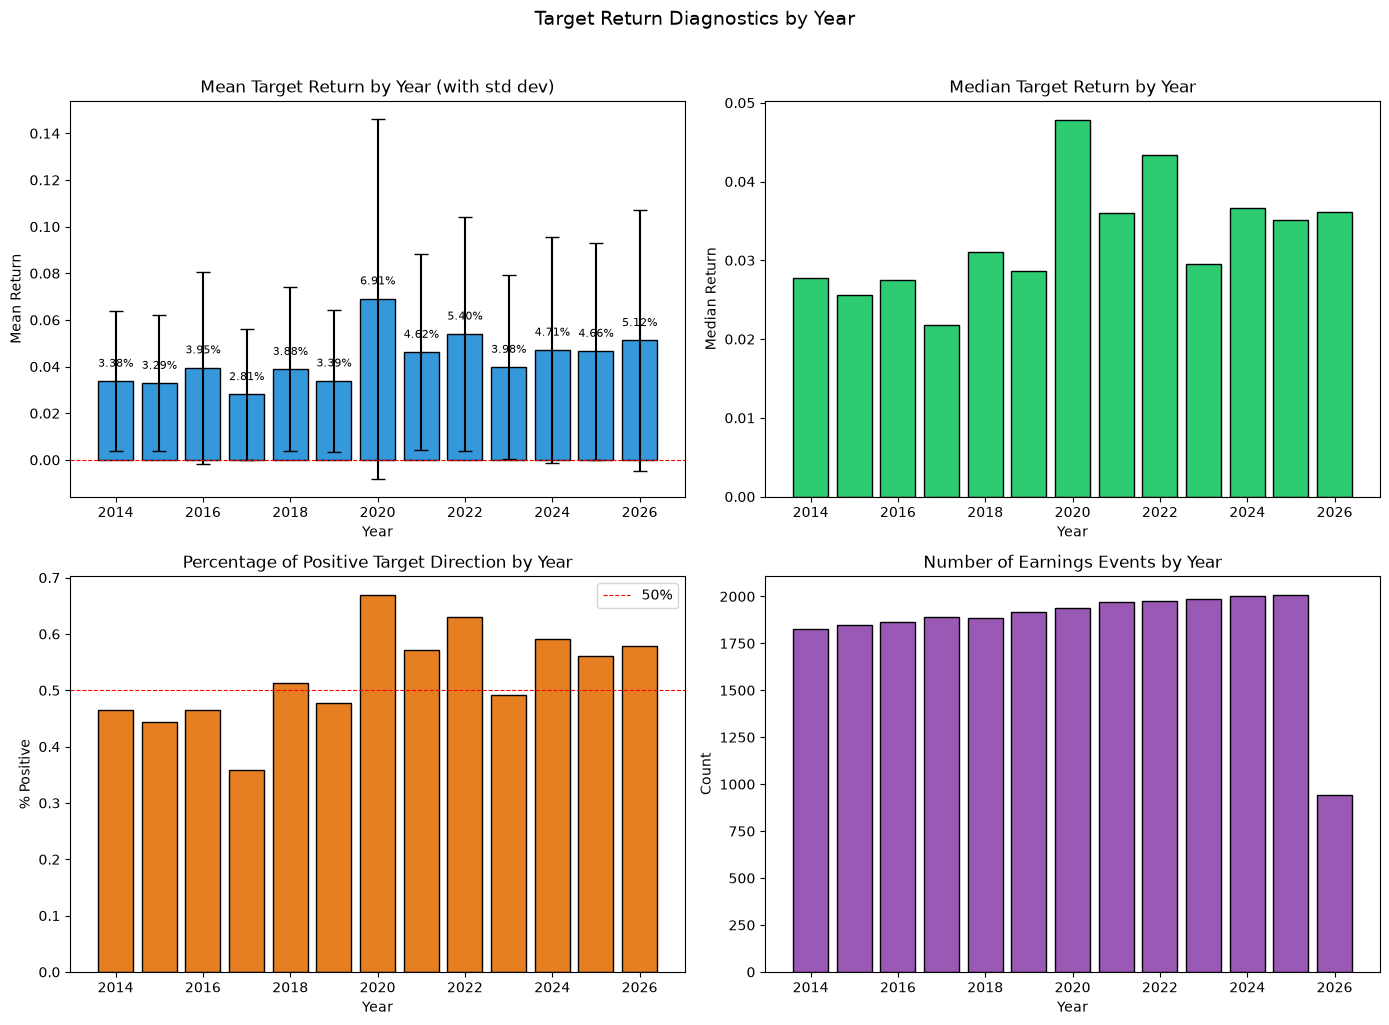


=== Temporal Split Summary ===
Fold 1 train sub (used for fitting): 2014-2018
Fold 1 val      (used by Optuna):    2019
Fold 1 test     (first test year):   2021
Fold 1 test: 2021
Fold 2 test: 2022
Fold 3 test: 2023
Fold 4 test: 2024
Fold 5 test: 2025


In [25]:
import matplotlib.pyplot as plt

# Extract year and compute yearly stats
df_plot = df_model.with_columns(
    pl.col("earnings_date").dt.year().alias("year")
)

yearly = df_plot.group_by("year").agg(
    pl.mean("target_return").alias("mean_return"),
    pl.median("target_return").alias("median_return"),
    pl.std("target_return").alias("std_return"),
    pl.mean("target_direction").alias("pct_positive"),
    pl.len().alias("count"),
).sort("year")

print("=== Target Return by Year ===")
print(yearly.to_pandas().to_string(index=False))
print()

years  = yearly["year"].to_list()
means  = yearly["mean_return"].to_list()
medians = yearly["median_return"].to_list()
stds   = yearly["std_return"].to_list()
pct_pos = yearly["pct_positive"].to_list()
counts = yearly["count"].to_list()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: mean return by year with error bars
ax = axes[0, 0]
bars = ax.bar(years, means, yerr=stds, capsize=5, color="#3498db", edgecolor="black")
ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{m:.2%}", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Year")
ax.set_ylabel("Mean Return")
ax.set_title("Mean Target Return by Year (with std dev)")

# Top-right: median return by year
ax = axes[0, 1]
ax.bar(years, medians, color="#2ecc71", edgecolor="black")
ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Median Return")
ax.set_title("Median Target Return by Year")

# Bottom-left: percentage positive by year
ax = axes[1, 0]
ax.bar(years, pct_pos, color="#e67e22", edgecolor="black")
ax.axhline(0.5, color="red", linestyle="--", linewidth=0.8, label="50%")
ax.set_xlabel("Year")
ax.set_ylabel("% Positive")
ax.set_title("Percentage of Positive Target Direction by Year")
ax.legend()

# Bottom-right: sample count by year
ax = axes[1, 1]
ax.bar(years, counts, color="#9b59b6", edgecolor="black")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.set_title("Number of Earnings Events by Year")

plt.suptitle("Target Return Diagnostics by Year", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print train/val/test split years
print("\n=== Temporal Split Summary ===")
print(f"Fold 1 train sub (used for fitting): 2014-2018")
print(f"Fold 1 val      (used by Optuna):    2019")
print(f"Fold 1 test     (first test year):   2021")
for f in folds_data:
    print(f"Fold {f['fold_num']} test: {f['test_year']}")

---
## 9. Single Split: XGBoost — Train up to 2023, Predict 2024-2025

Simple train/test split: use data through 2023 as training, 2024-2025 as test. Only XGBoost (default params).

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib.patches import Patch

def prepare_single_split(df_model, feature_cols, train_end, test_start, test_end):
    train = df_model.filter(pl.col("earnings_date") < train_end)
    test  = df_model.filter(
        (pl.col("earnings_date") >= test_start) & (pl.col("earnings_date") < test_end)
    )

    X_train = train.select(feature_cols).to_numpy()
    X_test  = test.select(feature_cols).to_numpy()
    X_train = np.where(np.isinf(X_train), np.nan, X_train)
    X_test  = np.where(np.isinf(X_test), np.nan, X_test)
    imp = SimpleImputer(strategy="median")
    X_train = imp.fit_transform(X_train)
    X_test  = imp.transform(X_test)

    return {
        "X_train": X_train, "X_test": X_test,
        "y_train_cls": train["target_direction"].to_numpy(),
        "y_test_cls":  test["target_direction"].to_numpy(),
        "y_train_ret": train["target_return"].to_numpy(),
        "y_test_ret":  test["target_return"].to_numpy(),
        "test_years": f"{test_start.year}-{test_end.year-1}",
        "n_train": len(X_train), "n_test": len(X_test),
    }

# Split A: train up to 2024, test 2024-2025
s1 = prepare_single_split(df_model, feature_cols,
    train_end=date(2024, 1, 1), test_start=date(2024, 1, 1), test_end=date(2026, 1, 1))
print(f"Split A (train 2014-2023, test 2024-2025):")
print(f"  Train: {s1['n_train']:,} samples ({2014}-{2023})")
print(f"  Test:  {s1['n_test']:,} samples ({2024}-{2025})")
print(f"  Test class balance: {s1['y_test_cls'].mean():.1%} positive")
print()

# Split B: train up to 2021, test 2021-2025
s2 = prepare_single_split(df_model, feature_cols,
    train_end=date(2021, 1, 1), test_start=date(2021, 1, 1), test_end=date(2026, 1, 1))
print(f"Split B (train 2014-2020, test 2021-2025):")
print(f"  Train: {s2['n_train']:,} samples (2014-2020)")
print(f"  Test:  {s2['n_test']:,} samples (2021-2025)")
print(f"  Test class balance: {s2['y_test_cls'].mean():.1%} positive")

splits = [("Train<2024, Test 2024-2025", s1), ("Train<2021, Test 2021-2025", s2)]

Split A (train 2014-2023, test 2024-2025):
  Train: 19,098 samples (2014-2023)
  Test:  4,008 samples (2024-2025)
  Test class balance: 57.7% positive

Split B (train 2014-2020, test 2021-2025):
  Train: 13,169 samples (2014-2020)
  Test:  9,937 samples (2021-2025)
  Test class balance: 56.9% positive


In [32]:
results = []

for name, s in splits:
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")

    # ── XGBoost Classifier ──
    xgb_c = XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=42)
    xgb_c.fit(s["X_train"], s["y_train_cls"])
    preds_c = xgb_c.predict(s["X_test"])
    probs_c = xgb_c.predict_proba(s["X_test"])

    acc  = accuracy_score(s["y_test_cls"], preds_c)
    f1   = f1_score(s["y_test_cls"], preds_c, average="weighted")
    auc  = roc_auc_score(s["y_test_cls"], probs_c)
    prec = precision_score(s["y_test_cls"], preds_c, average="weighted")
    rec  = recall_score(s["y_test_cls"], preds_c, average="weighted")

    # ── XGBoost Regressor ──
    xgb_r = XGBRegressor(n_estimators=200, random_state=42)
    xgb_r.fit(s["X_train"], s["y_train_ret"])
    preds_r = xgb_r.predict(s["X_test"])

    mae  = mean_absolute_error(s["y_test_ret"], preds_r)
    rmse = np.sqrt(mean_squared_error(s["y_test_ret"], preds_r))
    r2   = r2_score(s["y_test_ret"], preds_r)

    results.append({
        "name": name, "split": s,
        "clf": {"model": xgb_c, "preds": preds_c, "probs": probs_c},
        "reg": {"model": xgb_r, "preds": preds_r},
        "metrics": {
            "DA": acc, "F1": f1, "AUC": auc,
            "Prec": prec, "Rec": rec,
            "MAE": mae, "RMSE": rmse, "R²": r2,
        },
    })

    print(f"  XGB Classifier -> DA={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    print(f"  XGB Regressor  -> MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")

print(f"\n{'='*60}")
print(f"{'Split':<30} {'DA':>8} {'AUC':>8} {'MAE':>8} {'R²':>8}")
print(f"{'-'*60}")
for r in results:
    m = r['metrics']
    print(f"{r['name']:<30} {m['DA']:>8.4f} {m['AUC']:>8.4f} {m['MAE']:>8.4f} {m['R²']:>8.4f}")
# Add B4 reference
b4_rf_da = np.mean(b4["clf"]["Random Forest"]["fold_acc"])
b4_rf_auc = roc_auc_score(np.array(b4["clf"]["Random Forest"]["true"]),
                           np.array(b4["clf"]["Random Forest"]["probs"]))
b4_rf_mae = np.mean(b4["reg"]["Random Forest"]["fold_mae"])
b4_rf_r2 = r2_score(np.array(b4["reg"]["Random Forest"]["true"]),
                     np.array(b4["reg"]["Random Forest"]["preds"]))
print(f"{'B4 Reference (RF, 5-fold)':<30} {b4_rf_da:>8.4f} {b4_rf_auc:>8.4f} {b4_rf_mae:>8.4f} {b4_rf_r2:>8.4f}")


  Train<2024, Test 2024-2025
  XGB Classifier -> DA=0.5467  F1=0.5469  AUC=0.5666
  XGB Regressor  -> MAE=0.0306  RMSE=0.0461  R²=0.0577

  Train<2021, Test 2021-2025
  XGB Classifier -> DA=0.5727  F1=0.5703  AUC=0.5944
  XGB Regressor  -> MAE=0.0316  RMSE=0.0457  R²=0.0022

Split                                DA      AUC      MAE       R²
------------------------------------------------------------
Train<2024, Test 2024-2025       0.5467   0.5666   0.0306   0.0577
Train<2021, Test 2021-2025       0.5727   0.5944   0.0316   0.0022
B4 Reference (RF, 5-fold)        0.5905   0.6158   0.0296   0.1190


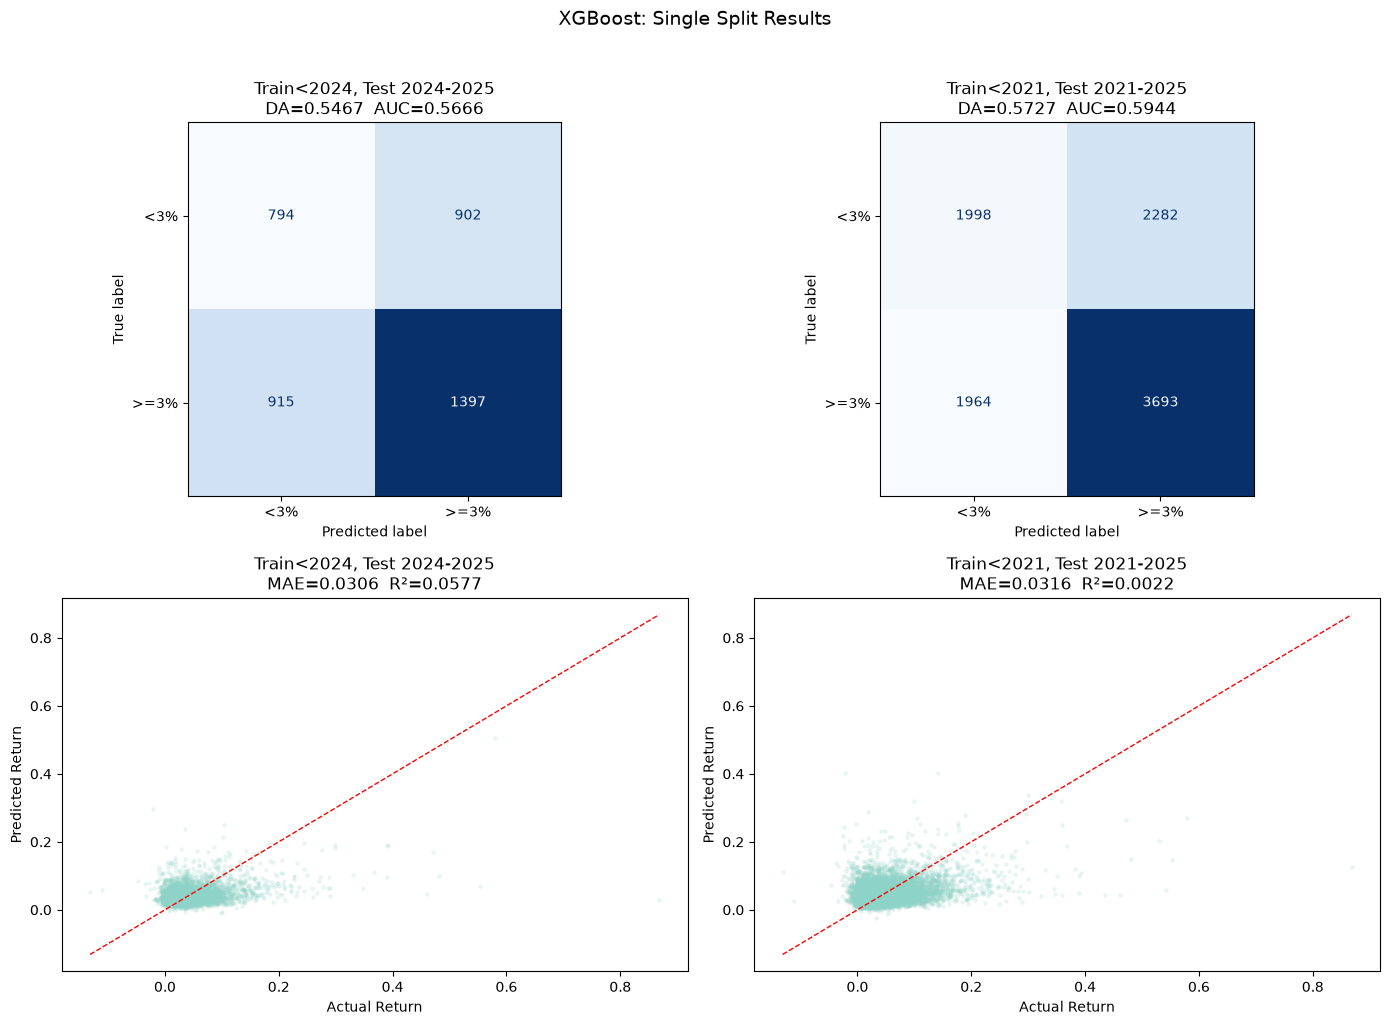

In [33]:
# ── Visualizations ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, r in enumerate(results):
    s = r['split']
    true_c = s['y_test_cls']
    true_r = s['y_test_ret']
    preds_c = r['clf']['preds']
    preds_r = r['reg']['preds']
    probs_c = r['clf']['probs']

    # Confusion Matrix
    ax = axes[0, idx]
    cm = confusion_matrix(true_c, preds_c)
    disp = ConfusionMatrixDisplay(cm, display_labels=["<3%", ">=3%"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{r['name']}\nDA={r['metrics']['DA']:.4f}  AUC={r['metrics']['AUC']:.4f}")

    # Predicted vs Actual return
    ax = axes[1, idx]
    ax.scatter(true_r, preds_r, alpha=0.15, s=5)
    lims = [min(true_r.min(), preds_r.min()), max(true_r.max(), preds_r.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlabel("Actual Return")
    ax.set_ylabel("Predicted Return")
    ax.set_title(f"{r['name']}\nMAE={r['metrics']['MAE']:.4f}  R²={r['metrics']['R²']:.4f}")

plt.suptitle("XGBoost: Single Split Results", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

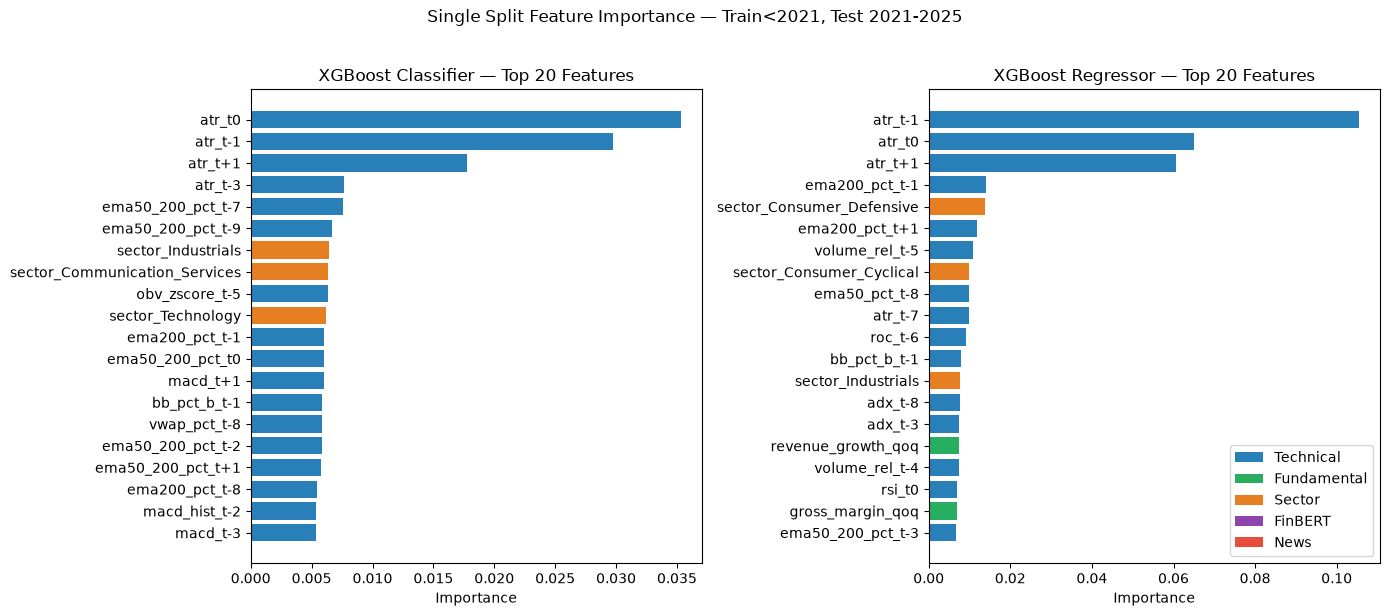

In [34]:
# ── Feature Importance (for the second / larger split) ──
r = results[1]  # Train<2021, Test 2021-2026

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

FUND_COLS = {
    "eps_growth_qoq", "revenue_growth_qoq", "gross_margin",
    "gross_margin_qoq", "debt_to_equity", "debt_to_equity_qoq",
    "fcf_margin", "fcf_margin_qoq", "roe", "roe_qoq",
    "surprisePercentage"
}
TRANSCRIPT_COLS = {"pos_prob", "neg_prob"}
NEWS_COLS = {
    "overall_sentiment_score_pre",  "ticker_sentiment_score_pre",
    "overall_sentiment_score_post", "ticker_sentiment_score_post",
}

def feature_color(name):
    if name.startswith("sector_"):  return "#e67e22"
    if name in FUND_COLS:           return "#27ae60"
    if name in TRANSCRIPT_COLS:     return "#8e44ad"
    if name in NEWS_COLS:           return "#e74c3c"
    return "#2980b9"

for ax, (label, imp) in zip(axes, [
    ("XGBoost Classifier", r['clf']['model'].feature_importances_),
    ("XGBoost Regressor",  r['reg']['model'].feature_importances_),
]):
    top_idx   = np.argsort(imp)[-20:]
    top_names = np.array(feature_cols)[top_idx]
    top_imp   = imp[top_idx]
    colors    = [feature_color(n) for n in top_names]
    ax.barh(top_names, top_imp, color=colors)
    ax.set_title(f"{label} \u2014 Top 20 Features")
    ax.set_xlabel("Importance")

legend_elements = [
    Patch(facecolor="#2980b9", label="Technical"),
    Patch(facecolor="#27ae60", label="Fundamental"),
    Patch(facecolor="#e67e22", label="Sector"),
    Patch(facecolor="#8e44ad", label="FinBERT"),
    Patch(facecolor="#e74c3c", label="News"),
]
axes[1].legend(handles=legend_elements, loc="lower right")

plt.suptitle(f"Single Split Feature Importance — {r['name']}", y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Target Variable Deep Dive — by Sector & Distribution

In [35]:
# Reload sector name mapping (sector name was dropped after creating dummies)
df_sector_names = (
    pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet")
    .select(["symbol", "sector"])
    .unique()
    .with_columns(pl.col("sector").fill_null("Unknown"))
)
df_viz = df_model.join(df_sector_names, on="symbol", how="left").with_columns(
    pl.col("earnings_date").dt.year().alias("year")
)

sectors_sorted = sorted(df_viz["sector"].unique().to_list())
print(f"Sectors: {sectors_sorted}")
print(f"Rows: {len(df_viz):,}")

Sectors: ['Basic Materials', 'Communication Services', 'Consumer Cyclical', 'Consumer Defensive', 'Energy', 'Financial Services', 'Healthcare', 'Industrials', 'Real Estate', 'Technology', 'Unknown', 'Utilities']
Rows: 24,048


=== Target Return Descriptive Statistics ===
 statistic        value
     count 24048.000000
null_count     0.000000
      mean     0.042991
       std     0.045487
       min    -0.131541
       25%     0.014795
       50%     0.031805
       75%     0.057408
       max     1.120253

Key Percentiles:
   1th: -0.0075 (-0.75%)
   5th: 0.0007 (0.07%)
  25th: 0.0148 (1.48%)
  50th: 0.0318 (3.18%)
  75th: 0.0574 (5.74%)
  90th: 0.0910 (9.10%)
  95th: 0.1213 (12.13%)
  99th: 0.2165 (21.65%)


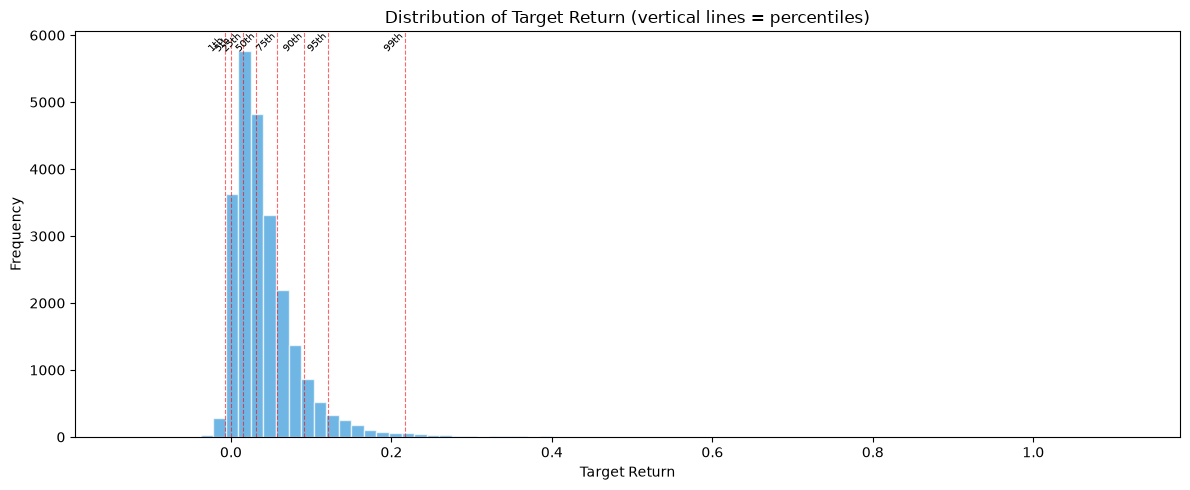

In [36]:
print("=== Target Return Descriptive Statistics ===")
stats = df_viz["target_return"].describe()
print(stats.to_pandas().to_string(index=False))
print()

percentiles = [1, 5, 25, 50, 75, 90, 95, 99]
p_vals = df_viz["target_return"].quantile([p/100 for p in percentiles])
print("Key Percentiles:")
for p, v in zip(percentiles, p_vals):
    print(f"  {p:>2}th: {v:.4f} ({v*100:.2f}%)")

fig, ax = plt.subplots(figsize=(12, 5))
returns = df_viz["target_return"].to_numpy()
ax.hist(returns, bins=80, color="#3498db", edgecolor="white", alpha=0.7)
for p, v in zip(percentiles, p_vals):
    ax.axvline(v, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.text(v, ax.get_ylim()[1]*0.95, f"{p}th", rotation=45, fontsize=7, ha="right")
ax.set_xlabel("Target Return")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Target Return (vertical lines = percentiles)")
plt.tight_layout()
plt.show()

In [37]:
sector_stats = df_viz.group_by("sector").agg(
    pl.len().alias("count"),
    pl.mean("target_return").alias("mean_return"),
    pl.median("target_return").alias("median_return"),
    pl.std("target_return").alias("std_return"),
    pl.mean("target_direction").alias("pct_positive"),
    pl.mean("pos_prob").alias("mean_pos_prob"),
).sort("mean_return", descending=True)

print("=== Target Return by Sector (sorted by mean return) ===\n")
print(sector_stats.to_pandas().to_string(index=False))

=== Target Return by Sector (sorted by mean return) ===

                sector  count  mean_return  median_return  std_return  pct_positive  mean_pos_prob
                Energy   1017     0.054766       0.040320    0.057516      0.617502       0.420431
            Technology   3863     0.050047       0.037393    0.054049      0.581672       0.461821
       Basic Materials    952     0.048810       0.035768    0.049972      0.574580       0.462417
Communication Services   1114     0.047469       0.032481    0.053475      0.527828       0.454782
     Consumer Cyclical   2583     0.047012       0.033404    0.053118      0.542393       0.482189
           Industrials   3515     0.042118       0.032288    0.039477      0.533713       0.453818
    Financial Services   3372     0.041449       0.031878    0.041615      0.526394       0.447324
            Healthcare   2845     0.040532       0.030760    0.039891      0.510369       0.471301
           Real Estate   1521     0.037420       0.0

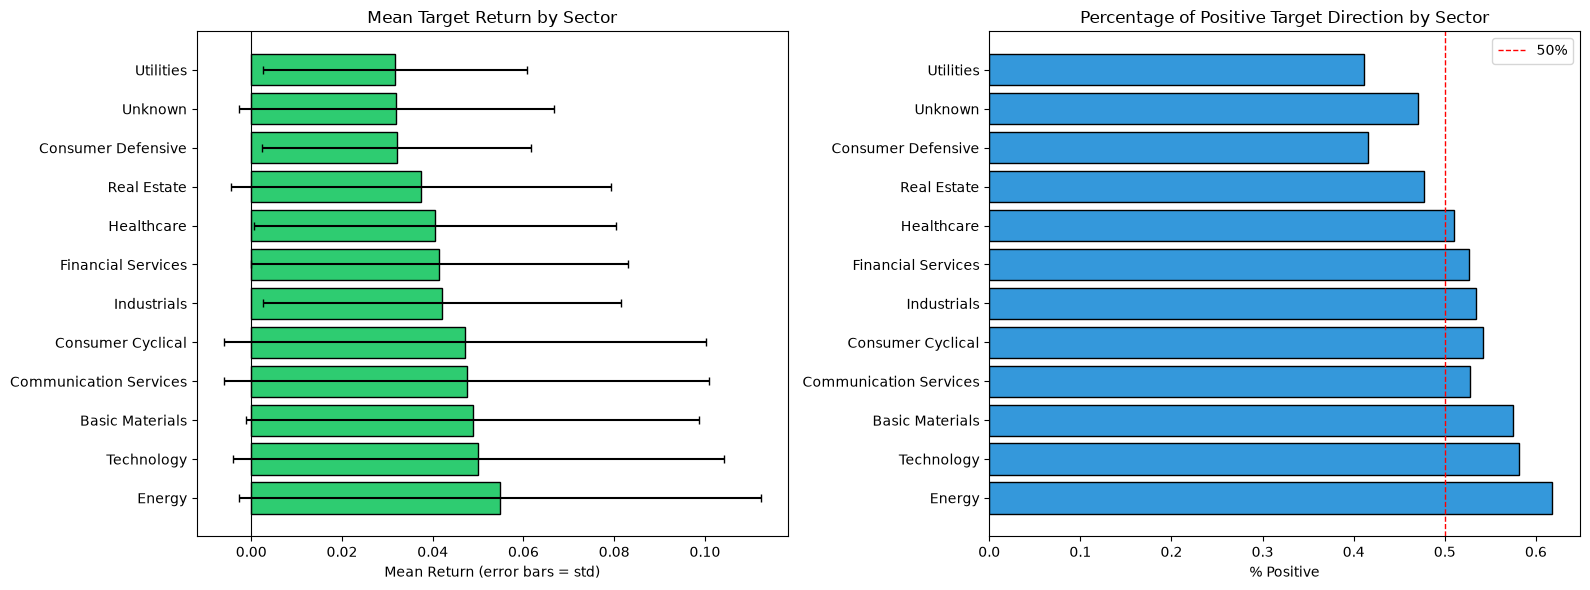

In [38]:
sector_plot = sector_stats.to_pandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: mean return by sector with std error bars
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in sector_plot["mean_return"]]
ax1.barh(sector_plot["sector"], sector_plot["mean_return"],
         xerr=sector_plot["std_return"], color=colors, edgecolor="black", capsize=3)
ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_xlabel("Mean Return (error bars = std)")
ax1.set_title("Mean Target Return by Sector")

# Right: percentage positive by sector
ax2.barh(sector_plot["sector"], sector_plot["pct_positive"],
         color="#3498db", edgecolor="black")
ax2.axvline(0.5, color="red", linestyle="--", linewidth=1, label="50%")
ax2.set_xlabel("% Positive")
ax2.set_title("Percentage of Positive Target Direction by Sector")
ax2.legend()

plt.tight_layout()
plt.show()

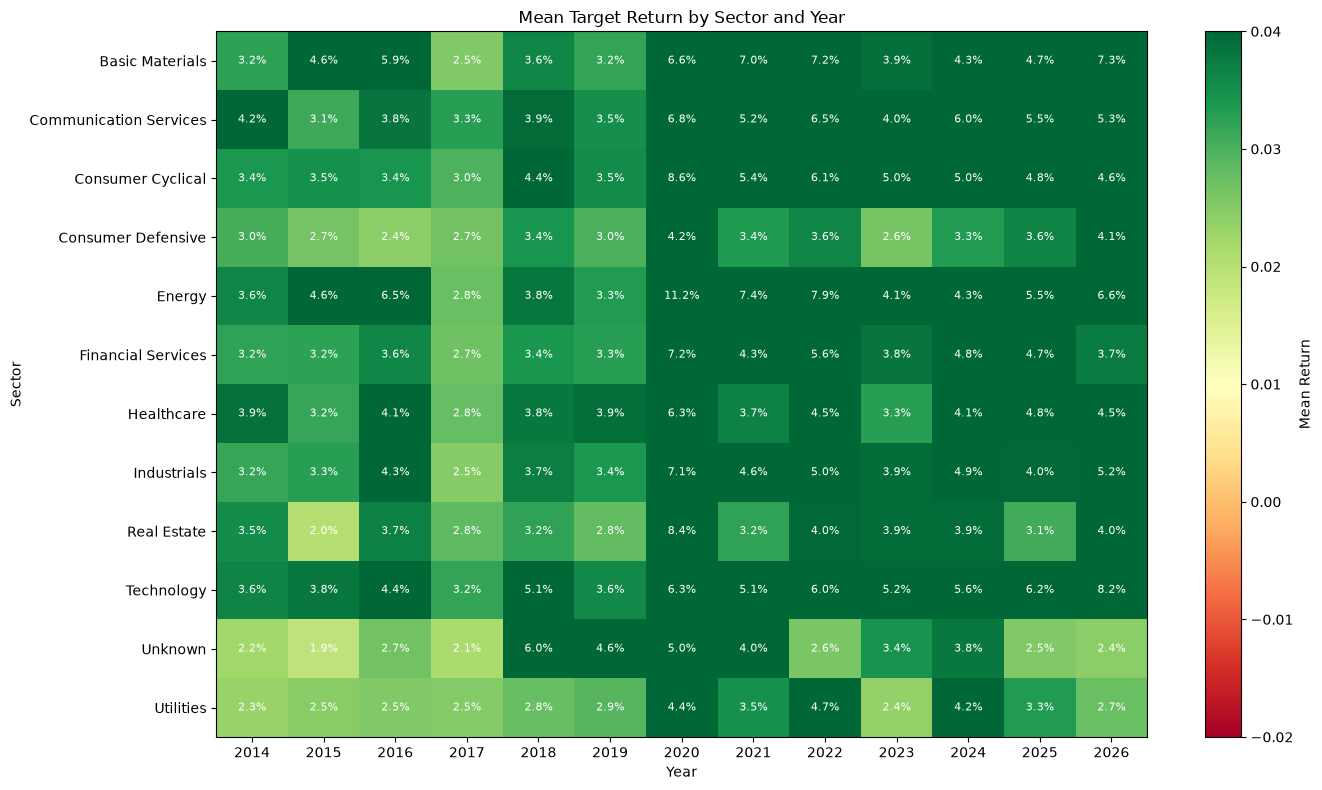

In [39]:
sector_year = df_viz.group_by(["sector", "year"]).agg(
    pl.mean("target_return").alias("mean_return")
).sort("year").to_pandas()

pivot = sector_year.pivot_table(
    index="sector", columns="year", values="mean_return", aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=-0.02, vmax=0.04)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Year")
ax.set_ylabel("Sector")
ax.set_title("Mean Target Return by Sector and Year")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        ax.text(j, i, f"{v:.1%}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > 0.015 else "black")

plt.colorbar(im, ax=ax, label="Mean Return")
plt.tight_layout()
plt.show()

In [40]:
os.makedirs("models", exist_ok=True)

for name, model in [("lr_clf", lr_model), ("ridge_reg", ridge_model),
                     ("rf_clf", rf_clf_model), ("rf_reg", rf_reg_model),
                     ("xgb_clf", xgb_clf_model), ("xgb_reg", xgb_reg_model)]:
    joblib.dump(model, f"models/b5_{name}.pkl")
    print(f"Saved models/b5_{name}.pkl")

pickle.dump(feature_cols, open("models/b5_feature_cols.pkl", "wb"))

pickle.dump({
    "clf": {"B0 Random": b0_clf, "LR (tuned)": lr_clf,
            "RF (tuned)": rf_clf, "XGB (tuned)": xgb_clf},
    "reg": {"B0 Mean": b0_reg, "Ridge (tuned)": ridge_reg,
            "RF (tuned)": rf_reg, "XGB (tuned)": xgb_reg},
    "best_params": best_params,
}, open("models/b5_results.pkl", "wb"))
print("Saved models/b5_results.pkl")

Saved models/b5_lr_clf.pkl
Saved models/b5_ridge_reg.pkl
Saved models/b5_rf_clf.pkl
Saved models/b5_rf_reg.pkl
Saved models/b5_xgb_clf.pkl
Saved models/b5_xgb_reg.pkl
Saved models/b5_results.pkl
